In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------------
# STEP 1: Load Bitcoin CSV Data
# -----------------------------------

df = pd.read_csv("data/bitcoin_20260512.csv")

# -----------------------------------
# STEP 2: Prepare Data
# -----------------------------------

# Convert timestamp column
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Convert to daily average prices
daily_df = df.resample("D").mean()

# Fill missing values
daily_df = daily_df.ffill()

# Use price series
series = daily_df["price"]

# -----------------------------------
# STEP 3: Train ARIMA Model
# -----------------------------------

model = ARIMA(
    series,
    order=(2,1,2)
)

model_fit = model.fit()

# -----------------------------------
# STEP 4: Predict Next 10 Days
# -----------------------------------

forecast = model_fit.forecast(steps=10)

# Create future dates
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=10,
    freq="D"
)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_price": forecast.values
})

# -----------------------------------
# STEP 5: Display Forecast
# -----------------------------------

print("\nPredicted Bitcoin Prices:")
print(forecast_df)

# -----------------------------------
# STEP 6: Plot Results
# -----------------------------------

plt.figure(figsize=(14,6))

# Historical prices
plt.plot(
    series.index,
    series.values,
    label="Historical Bitcoin Price"
)

# Forecast prices
plt.plot(
    forecast_df["date"],
    forecast_df["predicted_price"],
    label="10-Day Forecast"
)

# Labels and title
plt.title("Bitcoin Price Forecast using ARIMA")

plt.xlabel("Date")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.grid(True)

plt.show()

c:\Users\sidha\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ValueError: All arrays must be of the same length

c:\Users\sidha\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'



Predicted Bitcoin Prices for Next 30 Days:
         date  predicted_price
0  2026-05-13     80967.701357
1  2026-05-14     80758.279343
2  2026-05-15     81151.663953
3  2026-05-16     81532.018772
4  2026-05-17     81304.232293
5  2026-05-18     80825.042270
6  2026-05-19     80844.346920
7  2026-05-20     81331.667831
8  2026-05-21     81524.265992
9  2026-05-22     81120.956210
10 2026-05-23     80753.100442
11 2026-05-24     80996.241365
12 2026-05-25     81469.615467
13 2026-05-26     81432.435978
14 2026-05-27     80943.155630
15 2026-05-28     80767.570513
16 2026-05-29     81180.236108
17 2026-05-30     81535.156172
18 2026-05-31     81277.039992
19 2026-06-01     80810.083097
20 2026-06-02     80865.019893
21 2026-06-03     81355.607619
22 2026-06-04     81514.013634
23 2026-06-05     81092.571728
24 2026-06-06     80751.005305
25 2026-06-07     81023.699282
26 2026-06-08     81483.648444
27 2026-06-09     81411.094814
28 2026-06-10     80919.850993
29 2026-06-11     80778.76

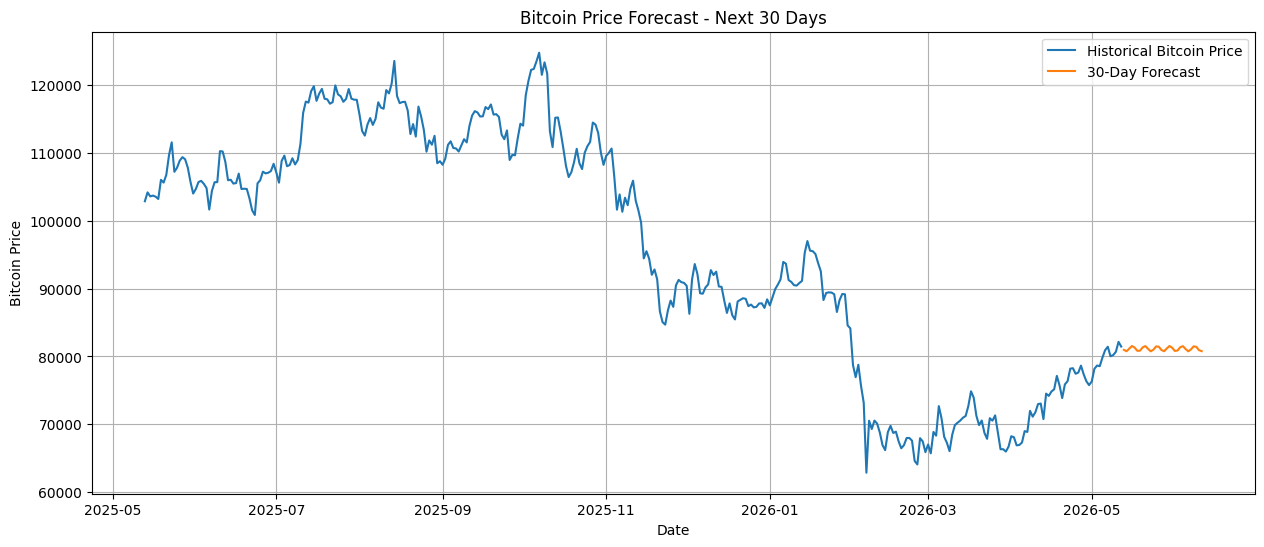

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# -----------------------------------
# STEP 1: Load Bitcoin CSV Data
# -----------------------------------

df = pd.read_csv("data/bitcoin_20260512.csv")

# -----------------------------------
# STEP 2: Prepare Data
# -----------------------------------

# Convert timestamp column
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Convert to daily average prices
daily_df = df.resample("D").mean()

# Fill missing values
daily_df = daily_df.ffill()

# Use price series
series = daily_df["price"]

# -----------------------------------
# STEP 3: Train ARIMA Model
# -----------------------------------

model = ARIMA(
    series,
    order=(2,1,2)
)

model_fit = model.fit()

# -----------------------------------
# STEP 4: Predict Next 30 Days
# -----------------------------------

forecast = model_fit.forecast(steps=30)

# Create future dates
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_price": forecast.values
})

# -----------------------------------
# STEP 5: Display Forecast
# -----------------------------------

print("\nPredicted Bitcoin Prices for Next 30 Days:")
print(forecast_df)

# -----------------------------------
# STEP 6: Plot Results
# -----------------------------------

plt.figure(figsize=(15,6))

# Historical prices
plt.plot(
    series.index,
    series.values,
    label="Historical Bitcoin Price"
)

# Forecast prices
plt.plot(
    forecast_df["date"],
    forecast_df["predicted_price"],
    label="30-Day Forecast"
)

# Labels and title
plt.title("Bitcoin Price Forecast - Next 30 Days")

plt.xlabel("Date")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.grid(True)

plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# -----------------------------------
# STEP 1: LOAD DATA
# -----------------------------------

df = pd.read_csv("data/bitcoin_20260512.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set index
df.set_index("timestamp", inplace=True)

# Daily average
daily_df = df.resample("D").mean()

# Fill missing values
daily_df = daily_df.ffill()

# Use price column
data = daily_df["price"].values.reshape(-1, 1)

# -----------------------------------
# STEP 2: SCALE DATA
# -----------------------------------

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

# -----------------------------------
# STEP 3: CREATE SEQUENCES
# -----------------------------------

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i, 0]
    )

    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = np.reshape(
    X,
    (X.shape[0], X.shape[1], 1)
)

# -----------------------------------
# STEP 4: BUILD LSTM MODEL
# -----------------------------------

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=64
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

# Compile model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# -----------------------------------
# STEP 5: TRAIN MODEL
# -----------------------------------

model.fit(
    X,
    y,
    epochs=20,
    batch_size=16,
    verbose=1
)

# -----------------------------------
# STEP 6: FORECAST NEXT 30 DAYS
# -----------------------------------

last_sequence = scaled_data[-sequence_length:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(30):

    prediction = model.predict(
        current_sequence.reshape(1, sequence_length, 1),
        verbose=0
    )

    future_predictions.append(
        prediction[0, 0]
    )

    current_sequence = np.append(
        current_sequence[1:],
        prediction
    )

# Convert back to actual prices
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

# -----------------------------------
# STEP 7: CREATE FUTURE DATES
# -----------------------------------

future_dates = pd.date_range(
    start=daily_df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_price": future_predictions.flatten()
})

# -----------------------------------
# STEP 8: DISPLAY FORECAST
# -----------------------------------

print("\n30-Day Bitcoin Forecast:")
print(forecast_df)

# -----------------------------------
# STEP 9: PLOT RESULTS
# -----------------------------------

plt.figure(figsize=(15,6))

# Historical prices
plt.plot(
    daily_df.index,
    daily_df["price"],
    label="Historical Bitcoin Price"
)

# Forecast prices
plt.plot(
    forecast_df["date"],
    forecast_df["predicted_price"],
    label="LSTM 30-Day Forecast"
)

# Labels
plt.title("Bitcoin Price Forecast using LSTM")

plt.xlabel("Date")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.grid(True)

plt.show()

ModuleNotFoundError: No module named 'tensorflow'

c:\Users\sidha\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 0.0826
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0108
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0095
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0089
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0086
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0072
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0085
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0077
Epoch 9/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0073
Epoch 10/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0090
Epoch 11/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0073
Epoch 12/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0072
Epoch 13/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0071
Epoch 14/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0056
Epoch 15/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0074
Epoc

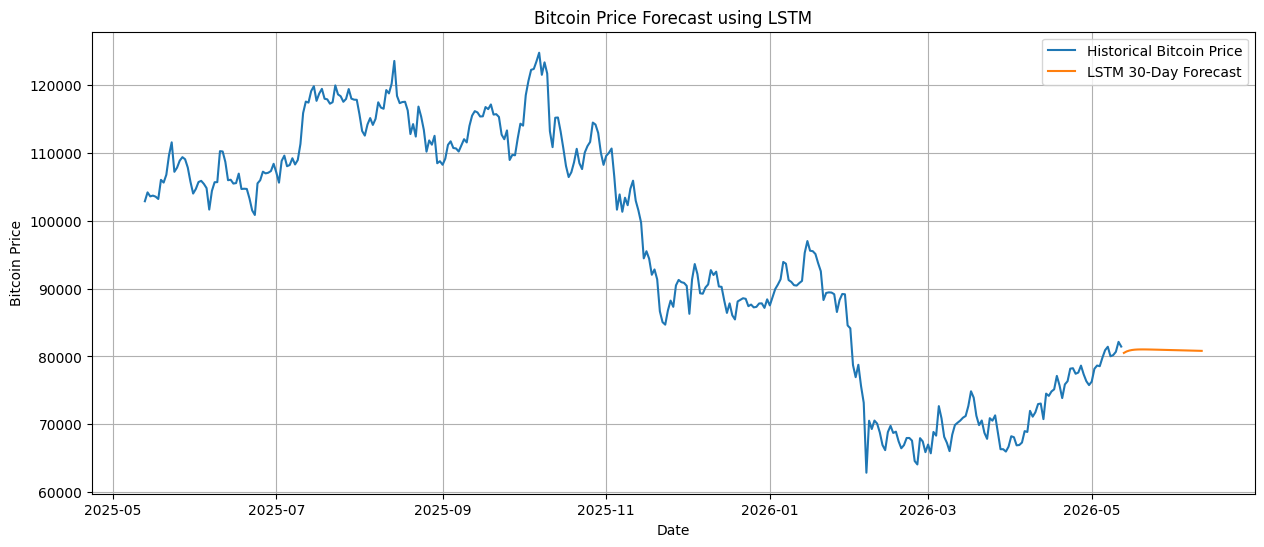

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# -----------------------------------
# STEP 1: LOAD DATA
# -----------------------------------

df = pd.read_csv("data/bitcoin_20260512.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set index
df.set_index("timestamp", inplace=True)

# Daily average
daily_df = df.resample("D").mean()

# Fill missing values
daily_df = daily_df.ffill()

# Use price column
data = daily_df["price"].values.reshape(-1, 1)

# -----------------------------------
# STEP 2: SCALE DATA
# -----------------------------------

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)

# -----------------------------------
# STEP 3: CREATE SEQUENCES
# -----------------------------------

sequence_length = 30

X = []
y = []

for i in range(sequence_length, len(scaled_data)):

    X.append(
        scaled_data[i-sequence_length:i, 0]
    )

    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

# Reshape for LSTM
X = np.reshape(
    X,
    (X.shape[0], X.shape[1], 1)
)

# -----------------------------------
# STEP 4: BUILD LSTM MODEL
# -----------------------------------

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(X.shape[1], 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=64
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

# Compile model
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

# -----------------------------------
# STEP 5: TRAIN MODEL
# -----------------------------------

model.fit(
    X,
    y,
    epochs=20,
    batch_size=16,
    verbose=1
)

# -----------------------------------
# STEP 6: FORECAST NEXT 30 DAYS
# -----------------------------------

last_sequence = scaled_data[-sequence_length:]

future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(30):

    prediction = model.predict(
        current_sequence.reshape(1, sequence_length, 1),
        verbose=0
    )

    future_predictions.append(
        prediction[0, 0]
    )

    current_sequence = np.append(
        current_sequence[1:],
        prediction
    )

# Convert back to actual prices
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

# -----------------------------------
# STEP 7: CREATE FUTURE DATES
# -----------------------------------

future_dates = pd.date_range(
    start=daily_df.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_price": future_predictions.flatten()
})

# -----------------------------------
# STEP 8: DISPLAY FORECAST
# -----------------------------------

print("\n30-Day Bitcoin Forecast:")
print(forecast_df)

# -----------------------------------
# STEP 9: PLOT RESULTS
# -----------------------------------

plt.figure(figsize=(15,6))

# Historical prices
plt.plot(
    daily_df.index,
    daily_df["price"],
    label="Historical Bitcoin Price"
)

# Forecast prices
plt.plot(
    forecast_df["date"],
    forecast_df["predicted_price"],
    label="LSTM 30-Day Forecast"
)

# Labels
plt.title("Bitcoin Price Forecast using LSTM")

plt.xlabel("Date")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.grid(True)

plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

from chronos import ChronosPipeline

# -----------------------------------
# STEP 1: LOAD DATA
# -----------------------------------

df = pd.read_csv("data/bitcoin_20260512.csv")

# Convert timestamp
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Convert to daily prices
daily_df = df.resample("D").mean()

# Fill missing values
daily_df = daily_df.ffill()

# Use price series
series = daily_df["price"]

# -----------------------------------
# STEP 2: LOAD CHRONOS MODEL
# -----------------------------------

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32
)

# -----------------------------------
# STEP 3: PREPARE CONTEXT
# -----------------------------------

context = torch.tensor(
    series.values,
    dtype=torch.float32
)

# -----------------------------------
# STEP 4: FORECAST NEXT 30 DAYS
# -----------------------------------

forecast = pipeline.predict(
    context=context,
    prediction_length=30
)

# Median forecast
forecast_values = forecast[0].median(dim=0).values.numpy()

# -----------------------------------
# STEP 5: CREATE FUTURE DATES
# -----------------------------------

future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_price": forecast_values
})

# -----------------------------------
# STEP 6: DISPLAY FORECAST
# -----------------------------------

print("\nChronos Forecast:")
print(forecast_df)

# -----------------------------------
# STEP 7: PLOT RESULTS
# -----------------------------------

plt.figure(figsize=(15,6))

# Historical prices
plt.plot(
    series.index,
    series.values,
    label="Historical Bitcoin Price"
)

# Forecast prices
plt.plot(
    forecast_df["date"],
    forecast_df["predicted_price"],
    label="Chronos Forecast"
)

# Labels
plt.title("Bitcoin Forecast using Amazon Chronos")

plt.xlabel("Date")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.grid(True)

plt.show()

c:\Users\sidha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\sidha\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sidha\.cache\huggingface\hub\models--amazon--chronos-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an 

TypeError: ChronosPipeline.predict() got an unexpected keyword argument 'context'


7-Day Bitcoin Forecast:

        date  predicted_price
0 2026-05-13     82228.554688
1 2026-05-14     82228.554688
2 2026-05-15     82228.554688
3 2026-05-16     81525.789062
4 2026-05-17     81525.789062
5 2026-05-18     82228.554688
6 2026-05-19     81525.789062


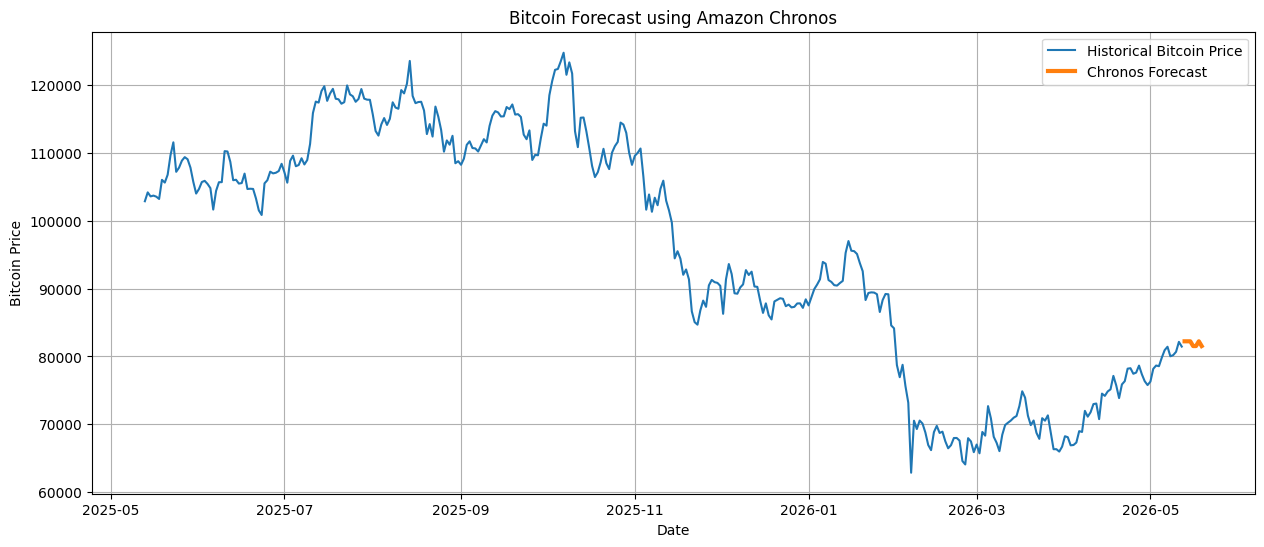

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import torch

from chronos import ChronosPipeline

# -----------------------------------
# STEP 1: LOAD DATA
# -----------------------------------

df = pd.read_csv("data/bitcoin_20260512.csv")

# Convert timestamp column
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Set timestamp as index
df.set_index("timestamp", inplace=True)

# Convert to daily average prices
daily_df = df.resample("D").mean()

# Fill missing values
daily_df = daily_df.ffill()

# Use only price series
series = daily_df["price"]

# -----------------------------------
# STEP 2: LOAD CHRONOS MODEL
# -----------------------------------

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",
    torch_dtype=torch.float32
)

# -----------------------------------
# STEP 3: PREPARE INPUT TENSOR
# -----------------------------------

context = torch.tensor(
    series.values,
    dtype=torch.float32
)

# -----------------------------------
# STEP 4: FORECAST NEXT 7 DAYS
# -----------------------------------

forecast = pipeline.predict(
    context,
    prediction_length=7
)

# -----------------------------------
# STEP 5: EXTRACT FORECAST VALUES
# -----------------------------------

# Use median prediction
forecast_values = forecast[0].median(dim=0).values.numpy()

# -----------------------------------
# STEP 6: CREATE FUTURE DATES
# -----------------------------------

future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

# -----------------------------------
# STEP 7: CREATE FORECAST DATAFRAME
# -----------------------------------

forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_price": forecast_values
})

# -----------------------------------
# STEP 8: DISPLAY FORECAST
# -----------------------------------

print("\n7-Day Bitcoin Forecast:\n")

print(forecast_df)

# -----------------------------------
# STEP 9: PLOT RESULTS
# -----------------------------------

plt.figure(figsize=(15,6))

# Historical data
plt.plot(
    series.index,
    series.values,
    label="Historical Bitcoin Price"
)

# Forecast data
plt.plot(
    forecast_df["date"],
    forecast_df["predicted_price"],
    label="Chronos Forecast",
    linewidth=3
)

# Labels
plt.title("Bitcoin Forecast using Amazon Chronos")

plt.xlabel("Date")

plt.ylabel("Bitcoin Price")

plt.legend()

plt.grid(True)

plt.show()